In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from core.dgp import IIDProcess, APDInnov, ARGARCHProcess
from core.models import IIDNormalModel, IIDNonNormalModel, AR1NormalModel, AR1NonNormalModel

In [7]:


N    = 1000
Ts = 15 + (300 - 15) * (np.linspace(0, 1, 80)**2) 
Ts = np.round(Ts).astype(int)
Ts = np.unique(Ts)
Ts   = [15, 30, 50, 100, 300]
rng  = np.random.default_rng(42)
dgp  = IIDProcess(APDInnov(alpha=0.7, lam=1.35)).calibrate_params(mu=0.5, sigma=1)
#dgp  = ARGARCHProcess().calibrate_params(mu=0.15, sigma=0.30)
models = [IIDNormalModel(), IIDNonNormalModel(), AR1NormalModel(), AR1NonNormalModel()]

records = []

for _ in range(N):
    for T in Ts:
        sample = dgp.simulate(T, rng)
        sr_h   = sample.mean() / sample.std(ddof=1)
        for model in models:
            name     = type(model).__name__
            params_h = model.fit(sample)
            sr_adj   = model.correct_bias(True, T, sr_h, **params_h)
            records.append({"T": T, "model": name, "estimate": sr_h, "corrected": sr_adj})

df = pd.DataFrame(records)
means = df.groupby(["model", "T"])[["estimate", "corrected"]].mean()

In [8]:
def plot_sharpe_bias(means, population_sr, model_names=None):
    fig, ax = plt.subplots(figsize=(8, 5))

    colors  = ["#1f4e9e", "#1a8a5e", "#b84a00", "#7b2d8b"]
    markers = ["s", "o", "^", "D"]
    Ts      = means.index.get_level_values("T").unique().sort_values()
    x       = list(range(len(Ts)))

    # shared lines
    shared = means.groupby("T")["estimate"].mean()
    ax.plot(x, shared.values, linestyle="--", marker="s", color="black",
            markersize=6, label="Estimate")
    ax.axhline(population_sr, color="black", linewidth=1.0, linestyle="-",
               label="Population")

    # one corrected line per model
    for i, (model_key, group) in enumerate(means.groupby("model")):
        label = model_names[i] if model_names else model_key
        ax.plot(x, group["corrected"].values, linestyle="-.",
                marker=markers[i % len(markers)], color=colors[i % len(colors)],
                markersize=6, label=f"{label} — bias corrected")

    ax.set_xticks(x)
    ax.set_xticklabels([str(t) for t in Ts])
    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("Sharpe ratio", fontsize=11)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.3f"))
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, linestyle=":", alpha=0.4)
    fig.tight_layout()
    return fig

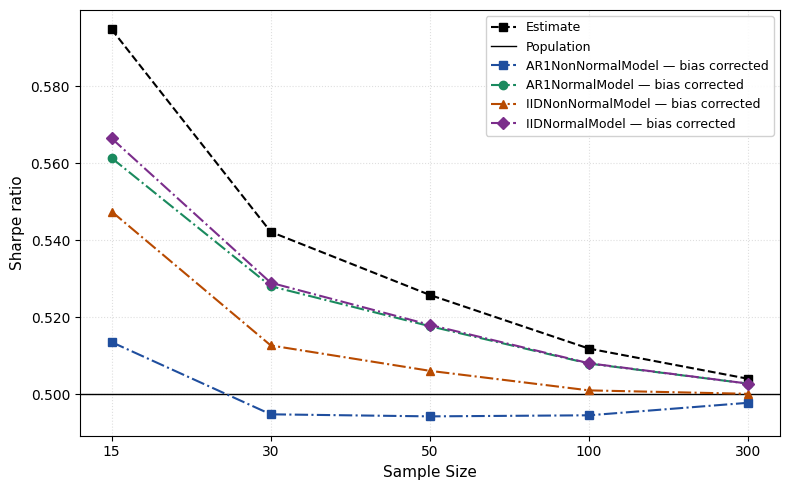

In [9]:
fig = plot_sharpe_bias(means, 0.5)